# COAD Kaplan-Meier Survival Analysis Report

**Date:** 2026-06-13  
**Cancer type:** COAD means colon adenocarcinoma (a type of colon cancer / 一种结肠癌).  
**Main method:** Kaplan-Meier curve (survival curve / 显示不同组病人生存比例随时间变化的图).

This report compares survival differences for:

1. **Stage II vs Stage III vs Stage IV**.
2. **High expression vs low expression of one selected gene**.
3. **Model-predicted high-risk group vs low-risk group**.

Survival analysis (生存分析 / 研究病人活多久以及哪些因素影响生存) uses follow-up time, so it is better than simply counting how many patients died.


## Important Definitions

- **Overall survival (OS):** time from diagnosis to death or last follow-up (总生存时间：从诊断到死亡或最后一次随访的时间).
- **Censored patient:** a patient whose death was not observed during follow-up (删失：随访结束时没有观察到死亡).
- **Log-rank test:** a statistical test for comparing survival curves (比较生存曲线是否不同的统计检验).
- **Hazard ratio (HR):** a relative risk score from survival models (风险比；HR > 1 usually means higher death risk, HR < 1 usually means lower death risk).
- **Gene expression:** how active a gene is in a sample (基因表达：一个基因在样本中有多活跃).

Important caveat: this is an observational analysis (观察性分析), so it can show association (相关), not prove causation (因果).


In [1]:
from pathlib import Path
import os
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from IPython.display import Markdown, display
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from sklearn.model_selection import StratifiedKFold
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 130

REPORT_DIR = Path.cwd()
if REPORT_DIR.name != "reports":
    REPORT_DIR = Path("/workspace/coad-predictor-model/reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)
PROJECT_ROOT = REPORT_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from src import config as project_config
except Exception:
    project_config = None


def get_db_setting(env_name, config_name, default=None):
    value = os.getenv(env_name)
    if value:
        return value
    if project_config is not None and hasattr(project_config, config_name):
        return getattr(project_config, config_name)
    return default


def make_engine():
    host = get_db_setting("PGHOST", "DB_HOST", "bio-postgres")
    port = int(get_db_setting("PGPORT", "DB_PORT", 5432))
    database = get_db_setting("PGDATABASE", "DB_NAME", "bio")
    user = get_db_setting("PGUSER", "DB_USER", "bio")
    password = get_db_setting("PGPASSWORD", "DB_PASSWORD")
    if not password:
        raise RuntimeError(
            "Database password was not found. Set PGPASSWORD or run from the "
            "coad-predictor-model project where src/config.py is available."
        )
    url = URL.create(
        "postgresql+psycopg2",
        username=user,
        password=password,
        host=host,
        port=port,
        database=database,
    )
    return create_engine(url)


def simplify_stage(value):
    if pd.isna(value):
        return pd.NA
    match = re.match(r"Stage\s+([IVX]+)", str(value))
    if not match:
        return pd.NA
    return f"Stage {match.group(1)}"


stage_order = ["Stage I", "Stage II", "Stage III", "Stage IV"]
stage_number = {stage: i + 1 for i, stage in enumerate(stage_order)}
engine = make_engine()
print("Report directory:", REPORT_DIR)
print("Database host:", engine.url.host, "database:", engine.url.database)

Report directory: /workspace/coad-predictor-model/reports
Database host: bio-postgres database: bio


## Load Clinical Survival Data

Clinical data come from `bio_tcga.tcga_cdr_tcga_cdr`, a curated TCGA clinical table.


In [2]:
clinical_query = """
SELECT
    bcr_patient_barcode AS patient_id,
    NULLIF(age_at_initial_pathologic_diagnosis, '#N/A')::double precision AS age,
    gender,
    ajcc_pathologic_tumor_stage AS stage_raw,
    vital_status,
    NULLIF(os, '#N/A')::integer AS os_event,
    NULLIF(os_time, '#N/A')::double precision AS os_time_days
FROM bio_tcga.tcga_cdr_tcga_cdr
WHERE type = 'COAD'
ORDER BY bcr_patient_barcode;
"""

clinical = pd.read_sql_query(text(clinical_query), engine)
missing_tokens = {"#N/A", "[Not Available]", "[Not Applicable]", ""}
for col in ["gender", "stage_raw", "vital_status"]:
    clinical[col] = clinical[col].replace(list(missing_tokens), pd.NA)

clinical["stage_group"] = clinical["stage_raw"].map(simplify_stage)
clinical["stage_group"] = pd.Categorical(
    clinical["stage_group"], categories=stage_order, ordered=True
)
clinical["stage_number"] = clinical["stage_group"].map(stage_number).astype(float)
clinical["male"] = (clinical["gender"] == "MALE").astype(float)
clinical["age_per_10_years"] = clinical["age"] / 10

survival = clinical.dropna(subset=["os_event", "os_time_days"]).query(
    "os_time_days > 0"
).copy()

summary = pd.DataFrame(
    {
        "metric": [
            "COAD patients",
            "Patients with usable OS",
            "Observed death events",
            "Patients with Stage II-IV and usable OS",
        ],
        "value": [
            len(clinical),
            len(survival),
            int(survival["os_event"].sum()),
            int(
                survival["stage_group"]
                .isin(["Stage II", "Stage III", "Stage IV"])
                .sum()
            ),
        ],
    }
)
display(summary)
display(survival.head())

,metric,value
0,COAD patients,459
1,Patients with usable OS,442
2,Observed death events,98
3,Patients with Stage II-IV and usable OS,357


,patient_id,age,gender,stage_raw,vital_status,os_event,os_time_days,stage_group,stage_number,male,age_per_10_years
0,TCGA-3L-AA1B,61.0,FEMALE,Stage I,Alive,0,475.0,Stage I,1.0,0.0,6.1
1,TCGA-4N-A93T,67.0,MALE,Stage IIIB,Alive,0,146.0,Stage III,3.0,1.0,6.7
2,TCGA-4T-AA8H,42.0,FEMALE,Stage IIA,Alive,0,385.0,Stage II,2.0,0.0,4.2
3,TCGA-5M-AAT4,74.0,MALE,Stage IV,Dead,1,49.0,Stage IV,4.0,1.0,7.4
4,TCGA-5M-AAT6,40.0,FEMALE,Stage IV,Dead,1,290.0,Stage IV,4.0,0.0,4.0


## Helper Functions for Survival Curves

In [3]:
def km_survival_table(data, group_col, ordered_groups=None):
    rows = []
    groups = ordered_groups or list(data[group_col].dropna().unique())
    for group in groups:
        group_data = data[data[group_col] == group]
        if group_data.empty:
            continue
        kmf = KaplanMeierFitter()
        kmf.fit(
            group_data["os_time_days"],
            event_observed=group_data["os_event"],
            label=str(group),
        )
        estimates = kmf.survival_function_at_times([365.25, 365.25 * 3, 365.25 * 5])
        rows.append(
            {
                "group": group,
                "patients": len(group_data),
                "death_events": int(group_data["os_event"].sum()),
                "1_year_survival_percent": estimates.iloc[0] * 100,
                "3_year_survival_percent": estimates.iloc[1] * 100,
                "5_year_survival_percent": estimates.iloc[2] * 100,
            }
        )
    table = pd.DataFrame(rows)
    rate_cols = [
        "1_year_survival_percent",
        "3_year_survival_percent",
        "5_year_survival_percent",
    ]
    if not table.empty:
        table[rate_cols] = table[rate_cols].round(1)
    return table


def plot_km(data, group_col, title, filename, ordered_groups=None, palette=None):
    fig, ax = plt.subplots(figsize=(8, 5.2))
    groups = ordered_groups or list(data[group_col].dropna().unique())
    for i, group in enumerate(groups):
        group_data = data[data[group_col] == group]
        if group_data.empty:
            continue
        kmf = KaplanMeierFitter()
        kmf.fit(
            group_data["os_time_days"],
            event_observed=group_data["os_event"],
            label=str(group),
        )
        color = None if palette is None else palette[i % len(palette)]
        kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=color)
    ax.set_title(title)
    ax.set_xlabel("Days since diagnosis")
    ax.set_ylabel("Estimated survival probability")
    ax.set_ylim(0, 1.03)
    ax.legend(title=group_col.replace("_", " "))
    fig.tight_layout()
    path = REPORT_DIR / filename
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    return path

## 1. Stage II vs Stage III vs Stage IV

Stage I is not included in this comparison because the requested comparison focuses on more advanced disease stages.


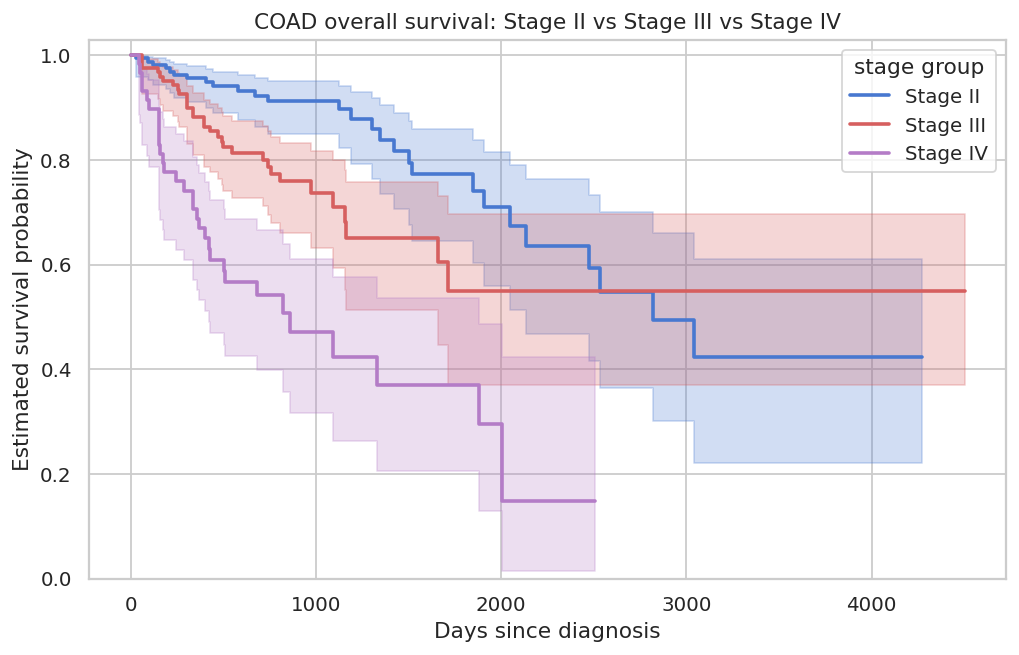

,group,patients,death_events,1_year_survival_percent,3_year_survival_percent,5_year_survival_percent
0,Stage II,169,27,95.6,91.3,77.2
1,Stage III,127,31,88.2,71.1,55.0
2,Stage IV,61,31,68.8,42.3,37.1


**Log-rank p-value:** 1.09e-10

Saved plot: `/workspace/coad-predictor-model/reports/coad_km_stage_ii_iii_iv.png`

In [4]:
stage_compare_order = ["Stage II", "Stage III", "Stage IV"]
stage_data = survival[survival["stage_group"].isin(stage_compare_order)].copy()
stage_data["stage_group"] = stage_data["stage_group"].astype(str)

stage_plot = plot_km(
    stage_data,
    group_col="stage_group",
    title="COAD overall survival: Stage II vs Stage III vs Stage IV",
    filename="coad_km_stage_ii_iii_iv.png",
    ordered_groups=stage_compare_order,
    palette=["#4878D0", "#D65F5F", "#B47CC7"],
)
stage_table = km_survival_table(
    stage_data, "stage_group", ordered_groups=stage_compare_order
)
stage_logrank = multivariate_logrank_test(
    stage_data["os_time_days"],
    stage_data["stage_group"],
    event_observed=stage_data["os_event"],
)
display(stage_table)
display(Markdown(f"**Log-rank p-value:** {stage_logrank.p_value:.2e}"))
display(Markdown(f"Saved plot: `{stage_plot}`"))

## Load Tumor Gene Expression Data

The gene-expression comparison uses tumor samples only. If one patient has more than one tumor sample, expression is averaged at the patient level.

Because the user did not specify a gene, the notebook selects one gene from the existing `important_genes.csv` candidate list. This is exploratory (探索性), so it should be treated as a hypothesis to test later, not a final clinical biomarker.


In [5]:
labels_path = PROJECT_ROOT / "data" / "coad_tumor_normal_labels.csv"
expr_path = PROJECT_ROOT / "data" / "coad_tumor_normal_raw_expression.parquet"
important_genes_path = REPORT_DIR / "important_genes.csv"

if not labels_path.exists() or not expr_path.exists():
    raise FileNotFoundError(
        "Expression data files were not found under /workspace/coad-predictor-model/data. "
        "Run the data preparation notebooks first."
    )
if not important_genes_path.exists():
    raise FileNotFoundError(
        "important_genes.csv was not found in reports. Run the model interpretation notebook first."
    )

labels = pd.read_csv(labels_path)
important_genes = pd.read_csv(important_genes_path)
candidate_genes = (
    important_genes["gene_symbol"].dropna().drop_duplicates().head(100).tolist()
)
schema_genes = set(pq.ParquetFile(expr_path).schema.names)
candidate_genes = [gene for gene in candidate_genes if gene in schema_genes]

expr = pd.read_parquet(expr_path, columns=candidate_genes)
tumor_labels = labels[labels["label"] == "tumor"].copy()
tumor_labels = tumor_labels[tumor_labels["sample_id"].isin(expr.index)]
tumor_expr = expr.loc[tumor_labels["sample_id"]].copy()
tumor_expr["patient_id"] = (
    tumor_labels.set_index("sample_id").loc[tumor_expr.index, "case_submitter_id"].values
)
patient_expr = tumor_expr.groupby("patient_id").mean(numeric_only=True)
merged = survival.merge(patient_expr, left_on="patient_id", right_index=True, how="inner")

display(
    pd.DataFrame(
        {
            "metric": [
                "Candidate genes scanned",
                "Patients with survival and tumor expression",
            ],
            "value": [len(candidate_genes), len(merged)],
        }
    )
)

,metric,value
0,Candidate genes scanned,82
1,Patients with survival and tumor expression,432


## 2. High Gene Expression vs Low Gene Expression

For each candidate gene, patients are split at the median expression value. Median split means half of patients are called "high expression" and half are called "low expression" (中位数分组：一半高表达，一半低表达).


In [6]:
gene_rows = []
for gene in candidate_genes:
    gene_data = merged[["os_time_days", "os_event", gene]].dropna().copy()
    if len(gene_data) < 80 or gene_data[gene].nunique() < 10:
        continue
    median_expr = gene_data[gene].median()
    gene_data["expression_group"] = np.where(
        gene_data[gene] >= median_expr, "High expression", "Low expression"
    )
    low = gene_data[gene_data["expression_group"] == "Low expression"]
    high = gene_data[gene_data["expression_group"] == "High expression"]
    if low.empty or high.empty:
        continue
    lr = logrank_test(
        low["os_time_days"],
        high["os_time_days"],
        event_observed_A=low["os_event"],
        event_observed_B=high["os_event"],
    )
    cox_gene = gene_data.copy()
    cox_gene["high_expression"] = (
        cox_gene["expression_group"] == "High expression"
    ).astype(int)
    cph = CoxPHFitter(penalizer=0.01)
    cph.fit(
        cox_gene[["os_time_days", "os_event", "high_expression"]],
        duration_col="os_time_days",
        event_col="os_event",
    )
    gene_rows.append(
        {
            "gene": gene,
            "patients": len(gene_data),
            "death_events": int(gene_data["os_event"].sum()),
            "median_expression": median_expr,
            "logrank_p": lr.p_value,
            "hr_high_vs_low": cph.summary.loc["high_expression", "exp(coef)"],
        }
    )

gene_scan = pd.DataFrame(gene_rows).sort_values("logrank_p").reset_index(drop=True)
gene_scan["fdr_q_value"] = multipletests(gene_scan["logrank_p"], method="fdr_bh")[1]
gene_scan_path = REPORT_DIR / "coad_survival_gene_candidate_scan.csv"
gene_scan.to_csv(gene_scan_path, index=False)
selected_gene = gene_scan.loc[0, "gene"]
selected_gene_median = merged[selected_gene].median()

display(gene_scan.head(10).round(4))
display(
    Markdown(
        f"Selected exploratory gene: **{selected_gene}**. "
        f"Candidate scan saved to `{gene_scan_path}`."
    )
)

,gene,patients,death_events,median_expression,logrank_p,hr_high_vs_low,fdr_q_value
0,CMC1,432,97,299.6885,0.0026,0.5535,0.2020
1,AP2M1,432,97,4671.3326,0.0119,1.6545,0.4667
2,POLR2J2,432,97,184.8440,0.0177,1.5903,0.4667
3,ATP13A2,432,97,1833.4284,0.0384,0.6659,0.6561
4,LYG1,432,97,5.8925,0.0588,1.4485,0.6561
5,SCG2,432,97,38.5548,0.0675,1.4290,0.6561
6,TRAPPC2L,432,97,614.9430,0.0728,0.7042,0.6561
7,WDR1,432,97,7694.7750,0.0735,0.7043,0.6561
8,SLC16A13,432,97,138.5832,0.0748,1.4169,0.6561
9,GPX4,432,97,2396.5967,0.0861,1.4007,0.6801


Selected exploratory gene: **CMC1**. Candidate scan saved to `/workspace/coad-predictor-model/reports/coad_survival_gene_candidate_scan.csv`.

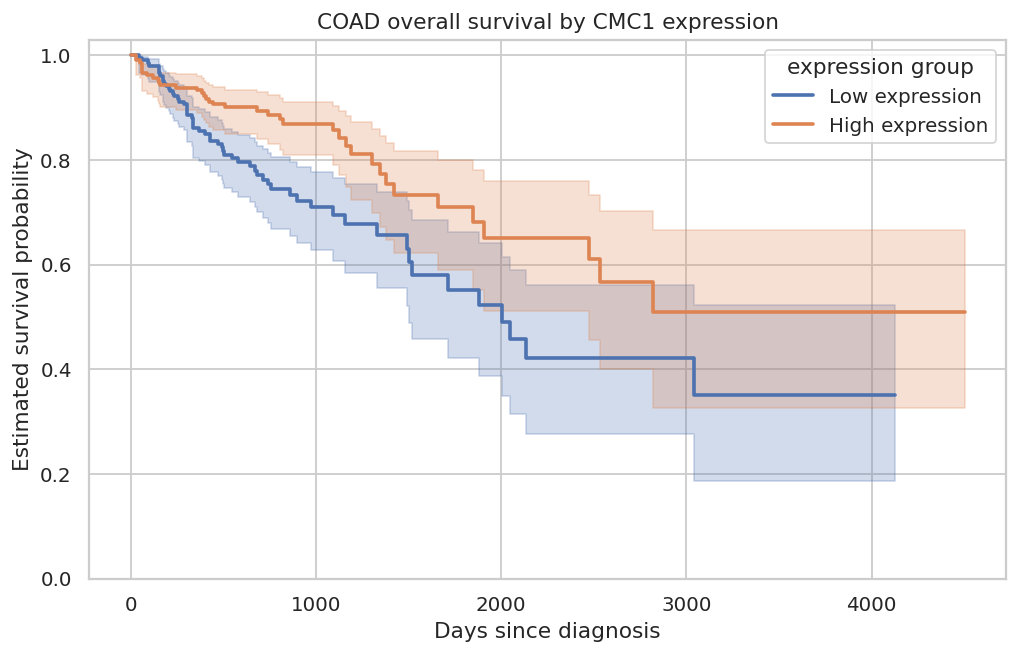

,group,patients,death_events,1_year_survival_percent,3_year_survival_percent,5_year_survival_percent
0,Low expression,216,59,86.0,69.4,55.1
1,High expression,216,38,93.3,85.7,71.0


**Log-rank p-value:** 0.0026

Saved plot: `/workspace/coad-predictor-model/reports/coad_km_gene_cmc1.png`

In [7]:
gene_data = merged[["patient_id", "os_time_days", "os_event", selected_gene]].dropna().copy()
gene_data["expression_group"] = np.where(
    gene_data[selected_gene] >= selected_gene_median,
    "High expression",
    "Low expression",
)
gene_order = ["Low expression", "High expression"]

gene_plot = plot_km(
    gene_data,
    group_col="expression_group",
    title=f"COAD overall survival by {selected_gene} expression",
    filename=f"coad_km_gene_{selected_gene.lower()}.png",
    ordered_groups=gene_order,
    palette=["#4C72B0", "#DD8452"],
)
gene_table = km_survival_table(
    gene_data, "expression_group", ordered_groups=gene_order
)
gene_low = gene_data[gene_data["expression_group"] == "Low expression"]
gene_high = gene_data[gene_data["expression_group"] == "High expression"]
gene_logrank = logrank_test(
    gene_low["os_time_days"],
    gene_high["os_time_days"],
    event_observed_A=gene_low["os_event"],
    event_observed_B=gene_high["os_event"],
)

display(gene_table)
display(Markdown(f"**Log-rank p-value:** {gene_logrank.p_value:.4f}"))
display(Markdown(f"Saved plot: `{gene_plot}`"))

## 3. Model-Predicted High-Risk Group vs Low-Risk Group

The previous project model predicts tumor vs normal, so it should not be called a survival-risk model. Here we build a small Cox survival model (a model that uses follow-up time and death/censoring / 使用随访时间和死亡或删失信息的模型).

Inputs:

- Age.
- Gender.
- Stage number.
- Selected gene expression.

To reduce over-optimism, the risk score is made with 5-fold out-of-fold prediction (每个病人的风险分数来自没有用这个病人训练的模型).


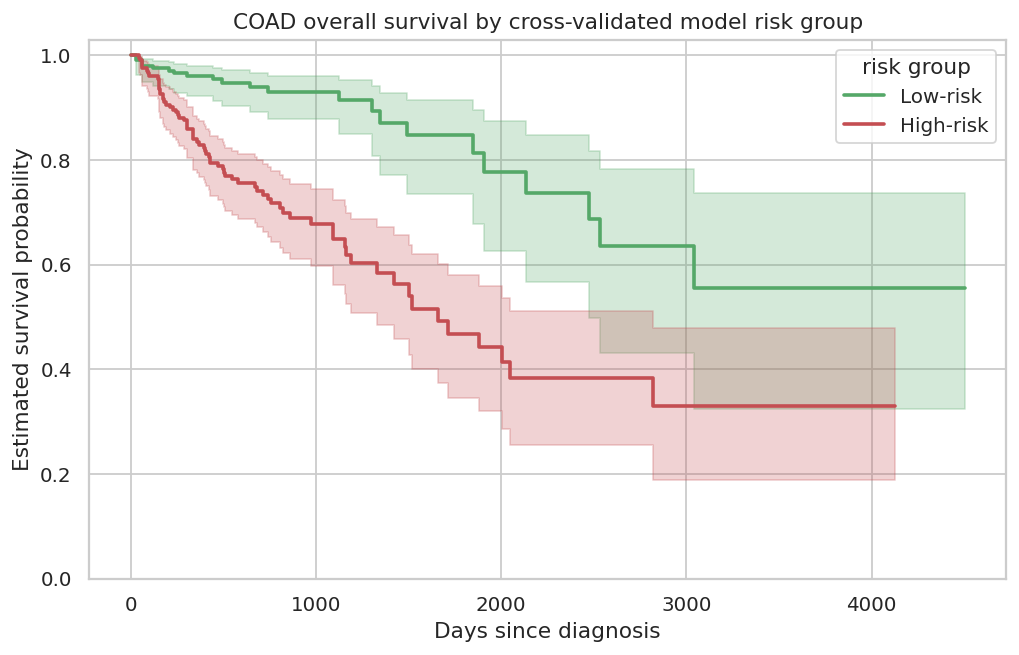

,hazard_ratio,hr_95ci_low,hr_95ci_high,p
covariate,,,,
"Age, per 10 years",1.183,1.033,1.356,0.015
Male vs female,1.082,0.768,1.523,0.653
"Stage, per level increase",1.754,1.446,2.129,0.000
"CMC1 expression, per SD",0.860,0.719,1.028,0.097


,group,patients,death_events,1_year_survival_percent,3_year_survival_percent,5_year_survival_percent
0,Low-risk,210,22,96.0,93.1,84.7
1,High-risk,211,70,83.4,64.9,46.8


**Log-rank p-value:** 1.09e-08

Saved plot: `/workspace/coad-predictor-model/reports/coad_km_model_risk_groups.png`

In [8]:
risk_df = merged[
    [
        "patient_id",
        "os_time_days",
        "os_event",
        "age_per_10_years",
        "male",
        "stage_number",
        selected_gene,
    ]
].dropna().copy()
risk_df["selected_gene_log2"] = np.log2(risk_df[selected_gene].clip(lower=0) + 1)
risk_df["selected_gene_z"] = (
    risk_df["selected_gene_log2"] - risk_df["selected_gene_log2"].mean()
) / risk_df["selected_gene_log2"].std(ddof=0)

feature_cols = ["age_per_10_years", "male", "stage_number", "selected_gene_z"]
risk_df["cv_risk_score"] = np.nan
splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in splitter.split(risk_df, risk_df["os_event"]):
    train = risk_df.iloc[train_idx]
    test = risk_df.iloc[test_idx]
    fold_model = CoxPHFitter(penalizer=0.1)
    fold_model.fit(
        train[["os_time_days", "os_event"] + feature_cols],
        duration_col="os_time_days",
        event_col="os_event",
    )
    risk_df.iloc[test_idx, risk_df.columns.get_loc("cv_risk_score")] = (
        fold_model.predict_partial_hazard(test[feature_cols]).values
    )

risk_cutoff = risk_df["cv_risk_score"].median()
risk_df["risk_group"] = np.where(
    risk_df["cv_risk_score"] >= risk_cutoff, "High-risk", "Low-risk"
)

final_model = CoxPHFitter(penalizer=0.1)
final_model.fit(
    risk_df[["os_time_days", "os_event"] + feature_cols],
    duration_col="os_time_days",
    event_col="os_event",
)
model_summary = final_model.summary[
    ["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]
].rename(
    columns={
        "exp(coef)": "hazard_ratio",
        "exp(coef) lower 95%": "hr_95ci_low",
        "exp(coef) upper 95%": "hr_95ci_high",
    },
    index={
        "age_per_10_years": "Age, per 10 years",
        "male": "Male vs female",
        "stage_number": "Stage, per level increase",
        "selected_gene_z": f"{selected_gene} expression, per SD",
    },
)

risk_plot = plot_km(
    risk_df,
    group_col="risk_group",
    title="COAD overall survival by cross-validated model risk group",
    filename="coad_km_model_risk_groups.png",
    ordered_groups=["Low-risk", "High-risk"],
    palette=["#55A868", "#C44E52"],
)
risk_table = km_survival_table(
    risk_df, "risk_group", ordered_groups=["Low-risk", "High-risk"]
)
low_risk = risk_df[risk_df["risk_group"] == "Low-risk"]
high_risk = risk_df[risk_df["risk_group"] == "High-risk"]
risk_logrank = logrank_test(
    low_risk["os_time_days"],
    high_risk["os_time_days"],
    event_observed_A=low_risk["os_event"],
    event_observed_B=high_risk["os_event"],
)

display(model_summary.round(3))
display(risk_table)
display(Markdown(f"**Log-rank p-value:** {risk_logrank.p_value:.2e}"))
display(Markdown(f"Saved plot: `{risk_plot}`"))

## Final Summary

In [9]:
stage_5y = stage_table.set_index("group")["5_year_survival_percent"].to_dict()
gene_5y = gene_table.set_index("group")["5_year_survival_percent"].to_dict()
risk_5y = risk_table.set_index("group")["5_year_survival_percent"].to_dict()

summary_text = f"""
### Answers

1. **Stage II vs III vs IV:** survival is clearly different by stage. The log-rank p-value is **{stage_logrank.p_value:.2e}**. Estimated 5-year survival is **{stage_5y.get('Stage II', np.nan):.1f}% for Stage II**, **{stage_5y.get('Stage III', np.nan):.1f}% for Stage III**, and **{stage_5y.get('Stage IV', np.nan):.1f}% for Stage IV**.

2. **Gene high vs low expression:** among the first 100 existing important-gene candidates, **{selected_gene}** had the strongest exploratory survival split. The log-rank p-value is **{gene_logrank.p_value:.4f}**. Estimated 5-year survival is **{gene_5y.get('Low expression', np.nan):.1f}% for low expression** and **{gene_5y.get('High expression', np.nan):.1f}% for high expression**.

3. **Model high-risk vs low-risk:** the cross-validated Cox risk model separates patients into visibly different survival groups. The log-rank p-value is **{risk_logrank.p_value:.2e}**. Estimated 5-year survival is **{risk_5y.get('Low-risk', np.nan):.1f}% for low-risk** and **{risk_5y.get('High-risk', np.nan):.1f}% for high-risk**.

### Plain English Takeaway

Stage remains the strongest clinical signal. Gene expression can add a possible biology clue, but the selected gene result is exploratory and needs validation. A survival-risk model can combine several factors into one risk score, but it should be tested on an independent dataset before clinical use.

### 中文简要总结

Stage（分期）仍然是最强的临床信号。基因表达可以提供生物学线索，但这里选出的基因结果是探索性的，需要后续验证。生存风险模型可以把年龄、性别、分期和基因表达合成一个风险分数，但真正用于临床前必须在独立数据集上测试。

### Limitations

- This is association, not causation (相关不等于因果).
- The selected gene was chosen by scanning candidates, so multiple testing may make the result look stronger than it really is.
- TCGA is a research cohort, not a perfect copy of real hospital patients.
- Treatment information and molecular subtype are not included here.
"""
display(Markdown(summary_text))


### Answers

1. **Stage II vs III vs IV:** survival is clearly different by stage. The log-rank p-value is **1.09e-10**. Estimated 5-year survival is **77.2% for Stage II**, **55.0% for Stage III**, and **37.1% for Stage IV**.

2. **Gene high vs low expression:** among the first 100 existing important-gene candidates, **CMC1** had the strongest exploratory survival split. The log-rank p-value is **0.0026**. Estimated 5-year survival is **55.1% for low expression** and **71.0% for high expression**.

3. **Model high-risk vs low-risk:** the cross-validated Cox risk model separates patients into visibly different survival groups. The log-rank p-value is **1.09e-08**. Estimated 5-year survival is **84.7% for low-risk** and **46.8% for high-risk**.

### Plain English Takeaway

Stage remains the strongest clinical signal. Gene expression can add a possible biology clue, but the selected gene result is exploratory and needs validation. A survival-risk model can combine several factors into one risk score, but it should be tested on an independent dataset before clinical use.

### 中文简要总结

Stage（分期）仍然是最强的临床信号。基因表达可以提供生物学线索，但这里选出的基因结果是探索性的，需要后续验证。生存风险模型可以把年龄、性别、分期和基因表达合成一个风险分数，但真正用于临床前必须在独立数据集上测试。

### Limitations

- This is association, not causation (相关不等于因果).
- The selected gene was chosen by scanning candidates, so multiple testing may make the result look stronger than it really is.
- TCGA is a research cohort, not a perfect copy of real hospital patients.
- Treatment information and molecular subtype are not included here.
